### Assigment 12

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File ko read karna
df = pd.read_csv('titanic_dataset.csv')

# list display
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.¶
X-axis: Embarked
Y-axis: Average of Survived
Add proper title and labels.
Identify which port has the highest survival rate.

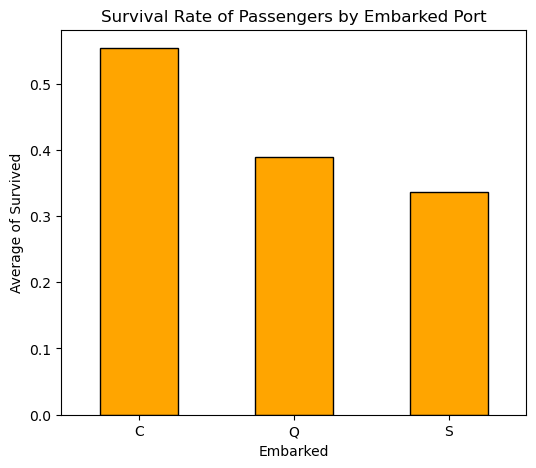

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [9]:
# Step 1: port survival rate
port_survival = df.groupby('Embarked')['Survived'].mean()

# Step 2: Create Bar Chart
plt.figure(figsize=(6, 5))
port_survival.plot(kind='bar', color='orange', edgecolor='black')

# Step 3: Labels and Title
plt.title('Survival Rate of Passengers by Embarked Port')
plt.xlabel('Embarked')
plt.ylabel('Average of Survived')
plt.xticks(rotation=0)

# Step 4: Chart display 
plt.show()

# Step 5: show numbers screen
print(port_survival)

### Q.2 Create a new column FamilySize using:
FamilySize = SibSp + Parch + 1
Then create a Count Plot showing the number of passengers for each family-size category.
X-axis: FamilySize
Y-axis: Number of Passengers
Identify the most common family size.¶

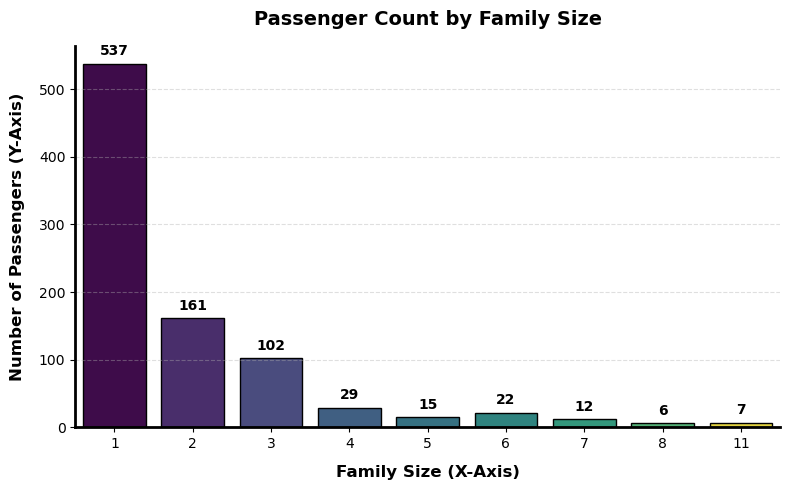

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [14]:
# Step 1: Create Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Step 2: Ready Plot Frame
fig, ax = plt.subplots(figsize=(8, 5))

# Step 3: Using Seaborn Count Plot draw 
sns.countplot(
    data=df, 
    x='FamilySize', 
    hue='FamilySize', 
    palette='viridis', 
    legend=False, 
    edgecolor='black', 
    ax=ax
)

# Step 4: X-axis aur Y-axis lines 
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Step 5: Title aur axis labels 
plt.title(
    'Passenger Count by Family Size', fontsize=14, fontweight='bold', pad=15
)
plt.xlabel('Family Size (X-Axis)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel(
    'Number of Passengers (Y-Axis)', fontsize=12, fontweight='bold', labelpad=10
)

# Step 6: show bar passenger exact counting numbers
for p in ax.patches:
  height = int(p.get_height())
  ax.annotate(
      f'{height}',
      (p.get_x() + p.get_width() / 2.0, height),
      ha='center',
      va='bottom',
      xytext=(0, 4),
      textcoords='offset points',
      fontweight='bold',
      fontsize=10,
  )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Step 7: print passengers counting
print(df['FamilySize'].value_counts().sort_index())

### Q3. Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.¶
X-axis: Pclass
Y-axis: Fare
Use Sex as hue.
Identify which group paid the highest fares.

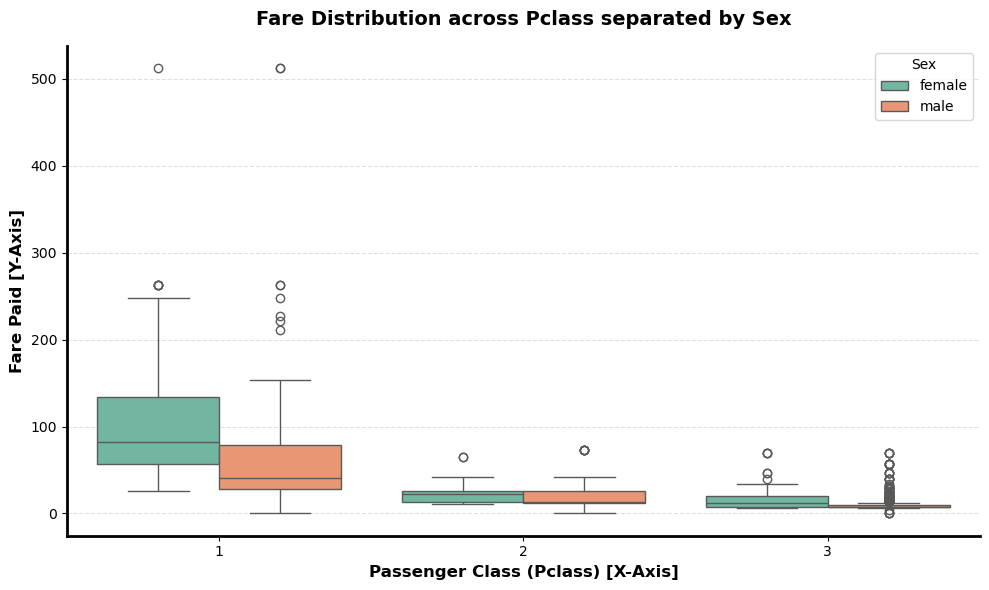

                    max        mean    median
Pclass Sex                                   
1      female  512.3292  106.125798  82.66455
       male    512.3292   67.226127  41.26250
2      female   65.0000   21.970121  22.00000
       male     73.5000   19.741782  13.00000
3      female   69.5500   16.118810  12.47500
       male     69.5500   12.661633   7.92500


In [17]:
# Step 1: Create Frame
fig, ax = plt.subplots(figsize=(10, 6))

# Step 2: Box Plot 
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Sex', palette='Set2', ax=ax)

# Step 3: X-axis aur Y-axis lines 
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Step 4: Labels and Title 
plt.title(
    'Fare Distribution across Pclass separated by Sex',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Passenger Class (Pclass) [X-Axis]', fontsize=12, fontweight='bold')
plt.ylabel('Fare Paid [Y-Axis]', fontsize=12, fontweight='bold')

# Step 5: Legend and Grid
plt.legend(title='Sex', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Step 6: Exact group Fare
print(df.groupby(['Pclass', 'Sex'])['Fare'].agg(['max', 'mean', 'median']))

### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.
X-axis: FamilySize
Y-axis: Survival Rate
Add markers to the line.
Identify the family size with the highest survival rate.

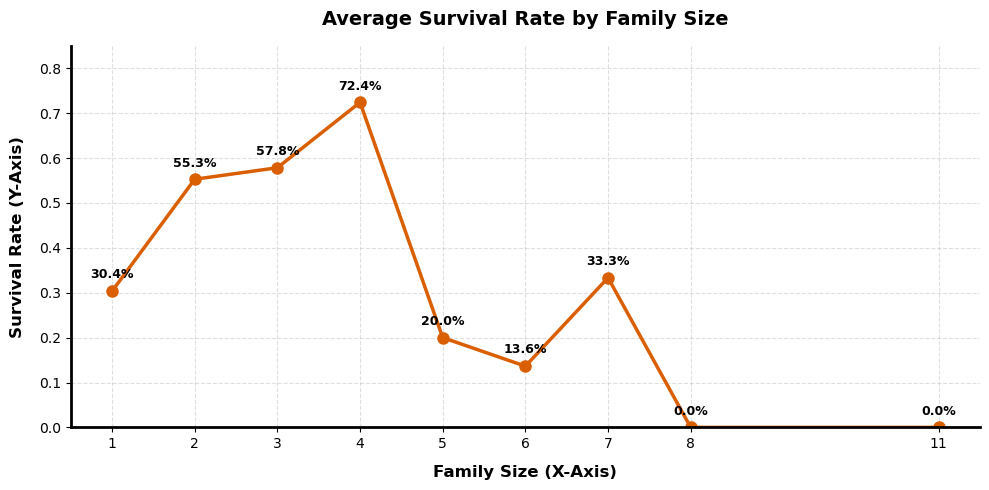

   FamilySize  Survived
0           1  0.303538
1           2  0.552795
2           3  0.578431
3           4  0.724138
4           5  0.200000
5           6  0.136364
6           7  0.333333
7           8  0.000000
8          11  0.000000


In [19]:
# Step 1: FamilySize average survival calculate 
family_survival = df.groupby('FamilySize')['Survived'].mean().reset_index()

# Step 2: Plot canvas ready 
fig, ax = plt.subplots(figsize=(10, 5))

# Step 3: Create Line plot with markers 
ax.plot(
    family_survival['FamilySize'],
    family_survival['Survived'],
    marker='o',
    markersize=8,
    color='#d95f02',
    linewidth=2.5,
)

# Step 4: X-axis aur Y-axis lines dark and clear 
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Step 5: Title aur axis labels 
plt.title(
    'Average Survival Rate by Family Size',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Family Size (X-Axis)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Survival Rate (Y-Axis)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(family_survival['FamilySize'])

# Step 6: point (marker) exact percentage 
for _, row in family_survival.iterrows():
  ax.annotate(
      f"{row['Survived']:.1%}",
      (row['FamilySize'], row['Survived']),
      ha='center',
      va='bottom',
      xytext=(0, 7),
      textcoords='offset points',
      fontweight='bold',
      fontsize=9,
  )

plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.ylim(0, 0.85)
plt.tight_layout()
plt.show()

# Step 7: Print Numbers screen 
print(family_survival)

### Q5.Passenger Class & Gender Survival Comparison
Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

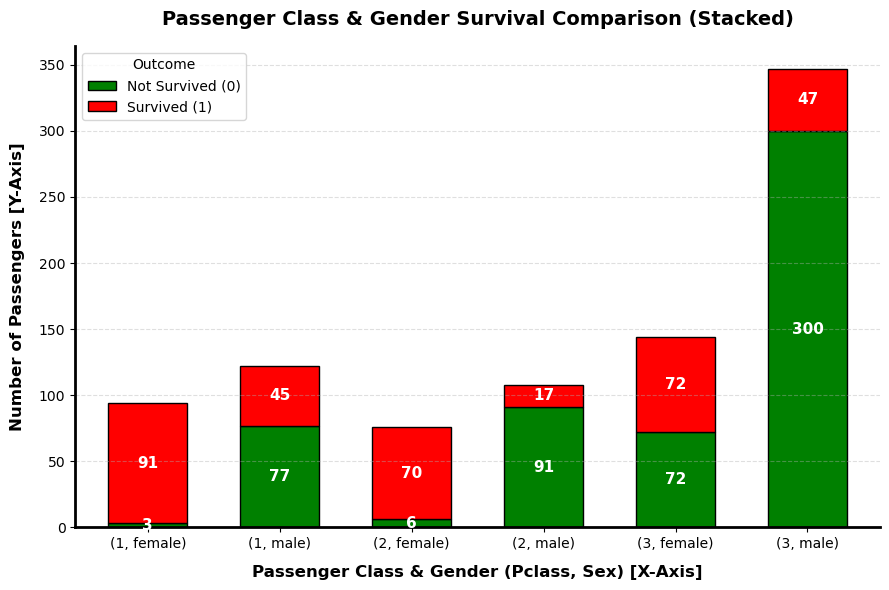

               Not Survived (0)  Survived (1)
Pclass Sex                                   
1      female                 3            91
       male                  77            45
2      female                 6            70
       male                  91            17
3      female                72            72
       male                 300            47


In [20]:
# Step 1: Pclass and Sex Survived/Not Survived 
survival_cross = pd.crosstab([df['Pclass'], df['Sex']], df['Survived'])
survival_cross.columns = ['Not Survived (0)', 'Survived (1)']

# Step 2: Ready Canvas 
fig, ax = plt.subplots(figsize=(9, 6))

# Step 3: Stacked Bar Chart 
survival_cross.plot(
    kind='bar',
    stacked=True,
    color=['Green', 'Red'],
    edgecolor='black',
    width=0.6,
    ax=ax,
)

# Step 4: X-axis aur Y-axis lines 
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Step 5: Title and Labels 
plt.title(
    'Passenger Class & Gender Survival Comparison (Stacked)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel(
    'Passenger Class & Gender (Pclass, Sex) [X-Axis]',
    fontsize=12,
    fontweight='bold',
    labelpad=10,
)
plt.ylabel(
    'Number of Passengers [Y-Axis]', fontsize=12, fontweight='bold', labelpad=10
)
plt.xticks(rotation=0, fontsize=10)
plt.legend(title='Outcome', frameon=True)

# Step 6: exact conting
for n, c in enumerate(survival_cross.columns):
  for i, val in enumerate(survival_cross[c]):
    if val > 0:
      cum_val = survival_cross.iloc[i, :n].sum() if n > 0 else 0
      y_pos = cum_val + val / 2
      ax.annotate(
          str(val),
          (i, y_pos),
          ha='center',
          va='center',
          color='white',
          fontweight='bold',
          fontsize=11,
      )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Step 7: table print 
print(survival_cross)